# **News Category**

---

News headline categorization with fine-tuned DistilBERT, BiLSTM, Logistic Regression, and Naive Bayes.

## **BiLSTM**

---

Trains a bidirectional LSTM over frozen GloVe word embeddings across the field configurations, scoring each on the held-out test split.

Outputs (under `results/bilstm/`):

- `scores.json`: test metrics per field configuration

- `best_params.json`: fixed architecture and training settings

### **Setup**

---

#### **Config**


In [1]:
import json
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import numpy as np
import gensim.downloader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from gensim.utils import simple_preprocess
from IPython.display import clear_output
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from news_category.data import load_split, assemble_fields, CONFIGS
from news_category.display import show
from news_category.evaluate import evaluate
from news_category.plotting import plot_confusion_matrix, plot_per_class_f1, plot_training_history, plot_metric_comparison

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
VERSION = "v1"
EMBEDDING = "glove-wiki-gigaword-300"
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.titleweight"] = "bold"
plt.rcParams["figure.titlesize"] = 18

#### **Load**


In [2]:
(df_train, df_test), labels = load_split(VERSION)
encoder = LabelEncoder().fit(labels)
glove = gensim.downloader.load(EMBEDDING)
show("Split Shapes", pd.DataFrame([df_train.shape, df_test.shape], index=["train", "test"], columns=["rows", "columns"]))

── Split Shapes ────────────────────────────


,rows,columns
train,167218,6
test,41805,6


### **Training**

---

For each field configuration, assemble the input text and tune the pipeline over the shared folds, scoring on the test split. The author-only configuration drops blank-author rows so it measures author signal fairly; the other configurations keep every row.


#### **Architecture**

A bidirectional LSTM over trainable GloVe embeddings, followed by dropout and a linear classifier.


In [3]:
EMBED_DIM = glove.vector_size
HIDDEN_SIZE = 128
DROPOUT = 0.3
BATCH_SIZE = 64
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-3
OOV_MIN_FREQ = 3

HYPERPARAMS = {
  "hidden_size": HIDDEN_SIZE,
  "dropout": DROPOUT,
  "batch_size": BATCH_SIZE,
  "max_epochs": MAX_EPOCHS,
  "patience": PATIENCE,
  "learning_rate": LEARNING_RATE,
  "embedding": EMBEDDING,
  "oov_min_freq": OOV_MIN_FREQ,
}


class BiLSTM(nn.Module):
  def __init__(self, embeddings: torch.Tensor, num_classes: int):
    super().__init__()
    self.embedding = nn.Embedding.from_pretrained(embeddings, freeze=False, padding_idx=0)
    self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_SIZE, batch_first=True, bidirectional=True)
    self.dropout = nn.Dropout(DROPOUT)
    self.linear = nn.Linear(2 * HIDDEN_SIZE, num_classes)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    _, (hidden, _) = self.lstm(self.embedding(x))
    pooled = torch.cat([hidden[0], hidden[1]], dim=1)
    return self.linear(self.dropout(pooled))

#### **Helpers**

Build a per-configuration vocabulary and GloVe embedding matrix, encode text to padded id sequences, and run the epoch loop with early stopping.


In [4]:
def build_embeddings(texts: pd.Series, verbose: bool = False) -> tuple:
  counts = Counter(word for text in texts for word in simple_preprocess(text))
  vocab = {"<pad>": 0, "<unk>": 1}
  matrix = [np.zeros(EMBED_DIM, dtype=np.float32)] * 2
  rng = np.random.default_rng(RANDOM_STATE)
  std = glove.vectors.std()
  for word in sorted(counts):
    if word in glove:
      vocab[word] = len(vocab)
      matrix.append(glove[word])
    elif counts[word] >= OOV_MIN_FREQ:
      vocab[word] = len(vocab)
      matrix.append(rng.normal(0, std, EMBED_DIM).astype(np.float32))
  if verbose:
    in_glove = sum(word in glove for word in counts)
    print(f"OOV Rate: {1 - in_glove / len(counts):.1%}")
  return vocab, torch.from_numpy(np.array(matrix))


def encode(texts: pd.Series, vocab: dict, max_len: int) -> torch.Tensor:
  sequences = []
  for text in texts:
    ids = [vocab.get(word, 1) for word in simple_preprocess(text)][:max_len]
    ids += [0] * (max_len - len(ids))
    sequences.append(ids)
  return torch.tensor(sequences, dtype=torch.long)


def loader(X: torch.Tensor, y: np.ndarray, shuffle: bool) -> DataLoader:
  dataset = TensorDataset(X, torch.tensor(y, dtype=torch.long))
  return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)


def macro_f1(model: nn.Module, data: DataLoader) -> tuple:
  model.eval()
  predictions, targets = [], []
  with torch.no_grad():
    for xb, yb in data:
      predictions.append(model(xb.to(DEVICE)).argmax(1).cpu())
      targets.append(yb)
  y_pred = torch.cat(predictions).numpy()
  y_true = torch.cat(targets).numpy()
  return y_pred, evaluate(y_true, y_pred)["f1"]


def train_model(
  model: nn.Module, train_data: DataLoader, val_data: DataLoader, weights: torch.Tensor, verbose: bool = False
) -> dict:
  loss_fn = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
  optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
  history = {"train": [], "validation": []}
  best_f1, best_state, waited = 0.0, None, 0
  for epoch in range(MAX_EPOCHS):
    model.train()
    for xb, yb in train_data:
      optimizer.zero_grad()
      loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE)).backward()
      optimizer.step()
    train_f1 = macro_f1(model, train_data)[1]
    val_f1 = macro_f1(model, val_data)[1]
    history["train"].append(train_f1)
    history["validation"].append(val_f1)
    if verbose:
      print(f"Epoch {epoch + 1:2d}/{MAX_EPOCHS}  train {train_f1:.3f}  val {val_f1:.3f}")
    if val_f1 > best_f1:
      best_f1, best_state, waited = val_f1, {k: v.cpu() for k, v in model.state_dict().items()}, 0
    else:
      waited += 1
      if waited >= PATIENCE:
        if verbose:
          print(f"Early stopped at epoch {epoch + 1}, best val {best_f1:.3f}")
        break
  model.load_state_dict(best_state)
  return history

#### **Per-Field Training**

Train the model for each field configuration and score the best epoch on the test split; the author-only configuration uses just the author-present rows.


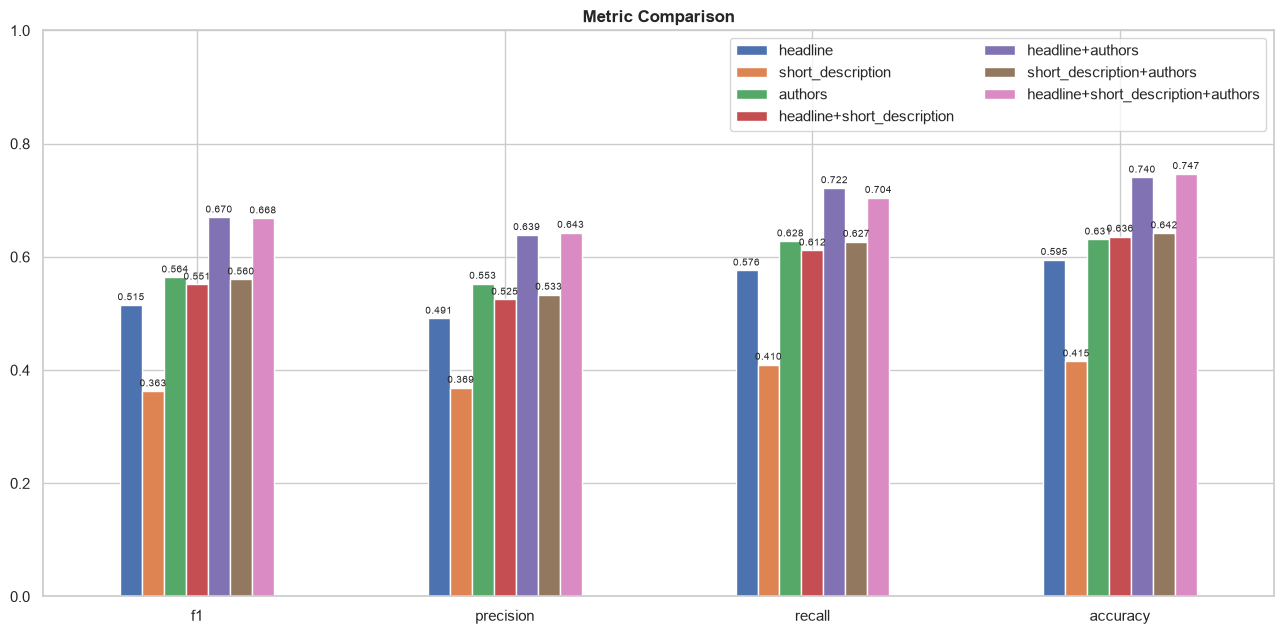

In [5]:
results = {}
predictions = {}
histories = {}
tests = {}

for config in CONFIGS:
  train_mask = df_train["has_author"] if config == "authors" else pd.Series(True, index=df_train.index)
  test_mask = df_test["has_author"] if config == "authors" else pd.Series(True, index=df_test.index)

  text_train = assemble_fields(df_train[train_mask], config)
  text_test = assemble_fields(df_test[test_mask], config)
  y_train = encoder.transform(df_train[train_mask]["category"])
  y_test = encoder.transform(df_test[test_mask]["category"])
  weights = torch.tensor(compute_class_weight("balanced", classes=np.arange(len(labels)), y=y_train), dtype=torch.float32)

  text_fit, text_val, y_fit, y_val = train_test_split(
    text_train, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE
  )

  show(config)
  vocab, matrix = build_embeddings(text_train, verbose=True)
  max_len = int(text_train.map(lambda text: len(simple_preprocess(text))).quantile(0.95))
  X_fit = encode(text_fit, vocab, max_len)
  X_val = encode(text_val, vocab, max_len)
  X_test = encode(text_test, vocab, max_len)

  model = BiLSTM(matrix, len(labels)).to(DEVICE)
  history = train_model(
    model,
    loader(X_fit, y_fit, shuffle=True),
    loader(X_val, y_val, shuffle=False),
    weights,
    verbose=True,
  )
  y_pred, _ = macro_f1(model, loader(X_test, y_test, shuffle=False))

  results[config] = evaluate(y_test, y_pred)
  predictions[config] = encoder.inverse_transform(y_pred)
  histories[config] = history
  tests[config] = encoder.inverse_transform(y_test)
  clear_output(wait=True)

fig, ax = plt.subplots(figsize=(13, 6.5))
plot_metric_comparison(results, ax=ax)
plt.tight_layout()
plt.show()

### **Diagnostics**

---

#### **Field Strengths & Weaknesses**

Three plots reveal what each configuration does well and poorly:

- **Confusion matrix**: which categories get mistaken for each other.

- **Per-class F1**: which categories the model handles worst.

- **Training history**: whether the model overfits as epochs progress..


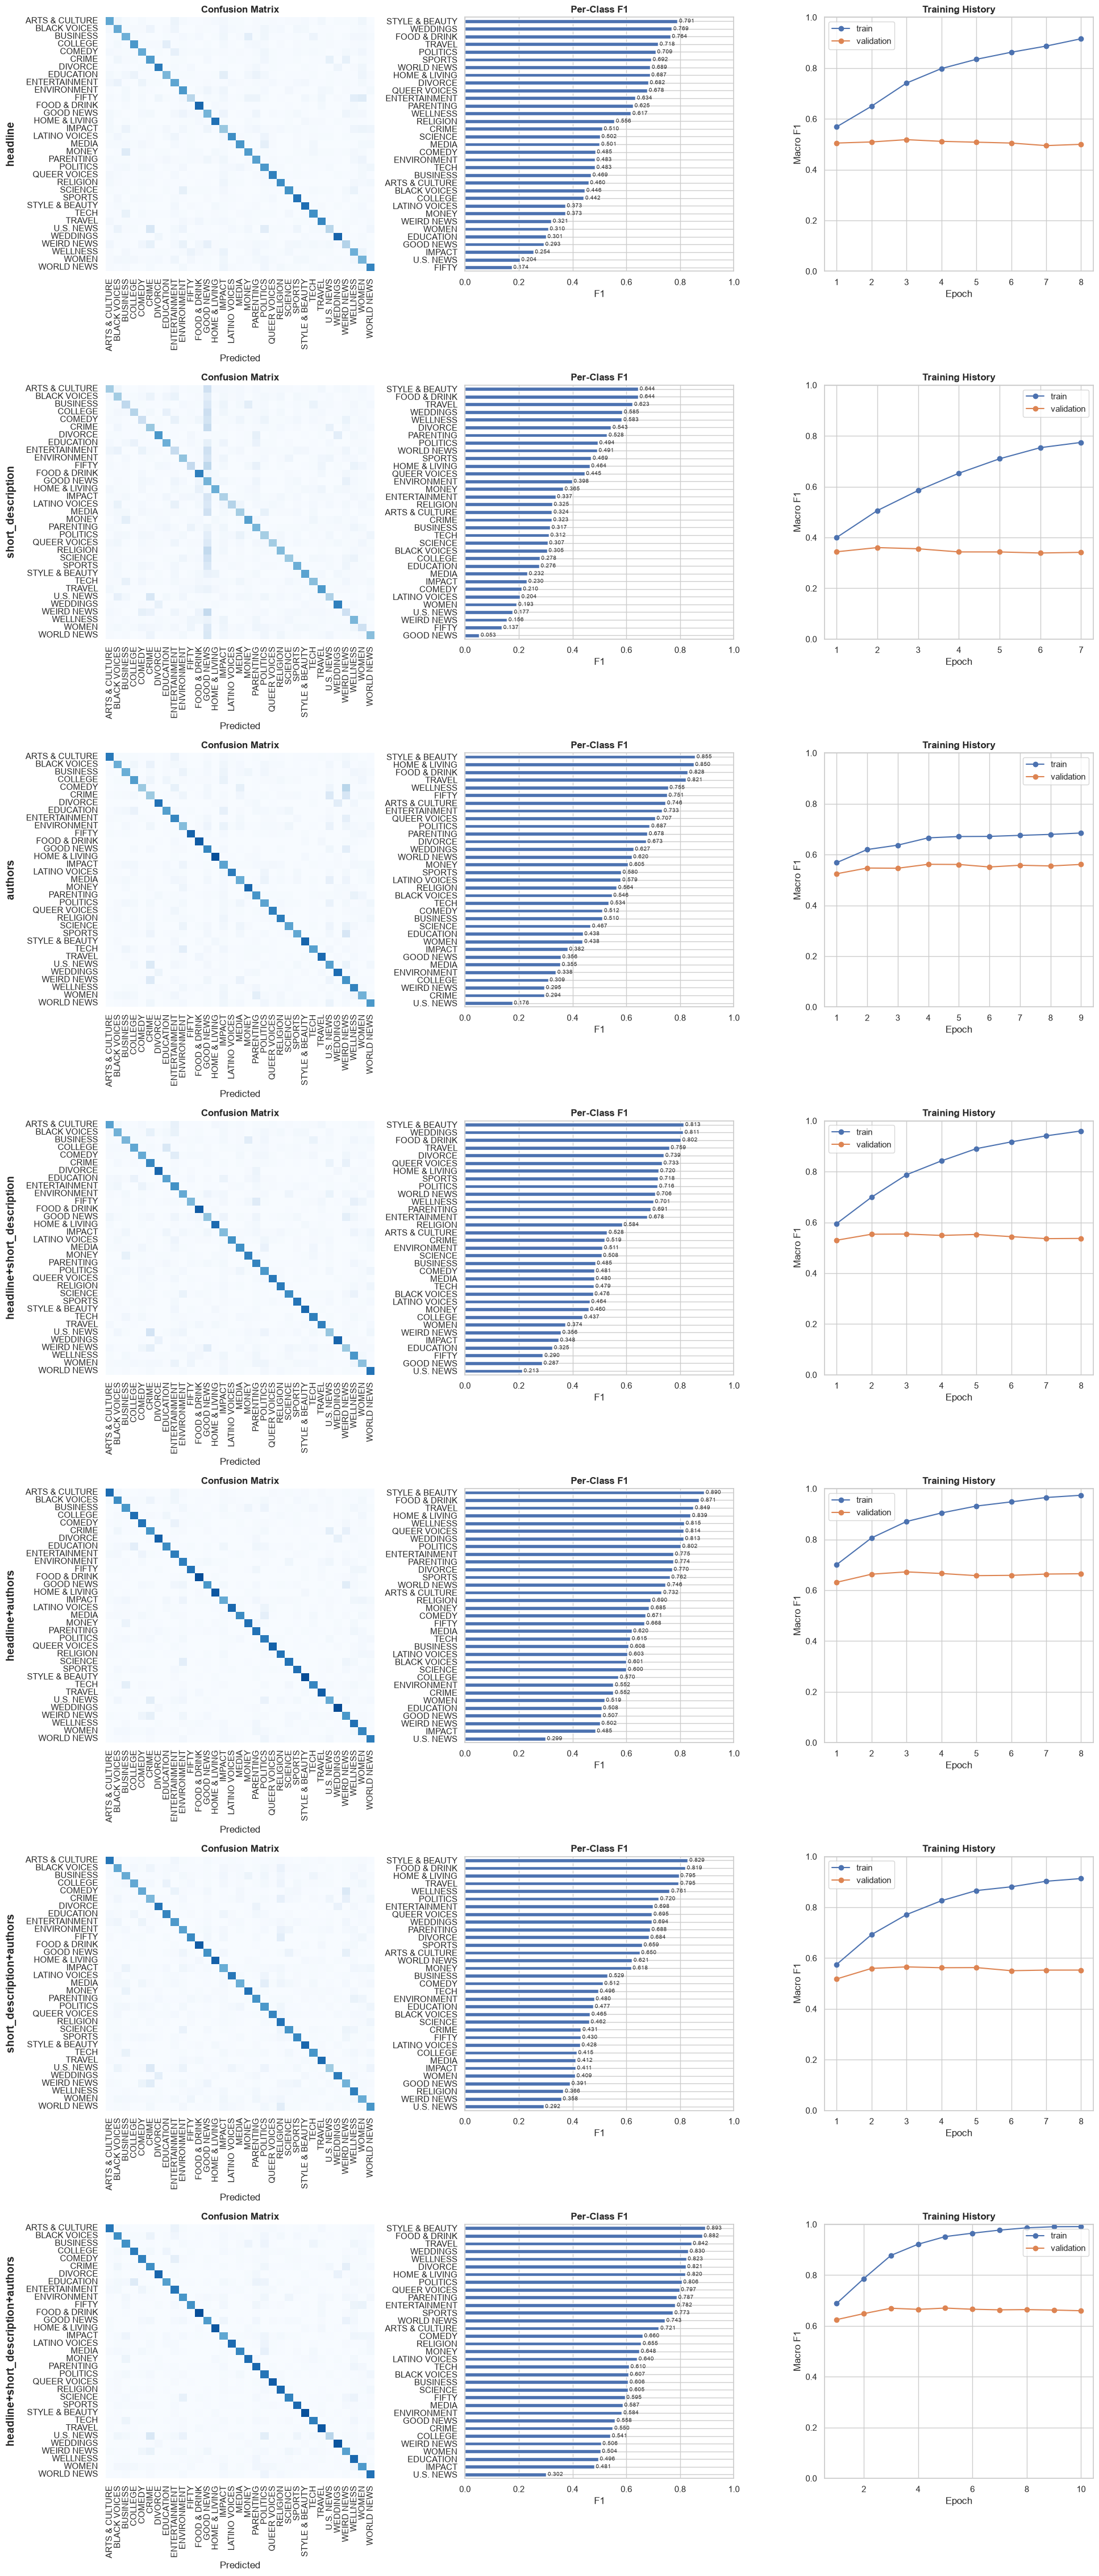

In [6]:
fig, axes = plt.subplots(len(CONFIGS), 3, figsize=(3 * 6.5, len(CONFIGS) * 6.5))
for row, config in zip(axes, CONFIGS):
  plot_confusion_matrix(tests[config], predictions[config], labels, ax=row[0])
  plot_per_class_f1(tests[config], predictions[config], labels, ax=row[1])
  plot_training_history(histories[config], ax=row[2])
  row[0].set_ylabel(config, fontsize=14, fontweight="bold", labelpad=12)
plt.tight_layout()
plt.show()

#### **Best Hyperparameters**

The fixed architecture and training settings behind every configuration's score.


In [7]:
show("Hyperparameters", pd.Series(HYPERPARAMS).to_frame("value"))

── Hyperparameters ─────────────────────────


,value
hidden_size,128
dropout,0.3
batch_size,64
max_epochs,30
patience,5
learning_rate,0.001
embedding,glove-wiki-gigaword-300
oov_min_freq,3


### **Output**

---

Write the per-configuration test scores and winning hyperparameters, for the comparison notebook.


In [8]:
DIR_OUT = Path("results/bilstm")
DIR_OUT.mkdir(parents=True, exist_ok=True)
with open(DIR_OUT / "scores.json", "w") as f:
  json.dump(results, f, indent=2)
with open(DIR_OUT / "best_params.json", "w") as f:
  json.dump({config: HYPERPARAMS for config in CONFIGS}, f, indent=2)
show("Saved", str(DIR_OUT))

── Saved ───────────────────────────────────
results/bilstm
